In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import (BaggingClassifier, RandomForestClassifier,
                              AdaBoostClassifier, GradientBoostingClassifier,
                              VotingClassifier, StackingClassifier)
from sklearn.metrics import accuracy_score, f1_score, classification_report

sns.set_style("whitegrid")

### Task 1: Baseline with Single Models

Load the data and establish individual model baselines.

1. Load the Wine Quality dataset and create a binary target:

```python
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
wine = pd.read_csv(url, sep=";")
wine["quality_label"] = (wine["quality"] >= 7).astype(int)  # 1 = good, 0 = not good
```

2. Explore the dataset: how many features? What's the class distribution of `quality_label`? Is the dataset imbalanced?
3. Separate features and target. Drop the original `quality` column.
4. Split into training and test sets (80/20, `stratify=y`, `random_state=42`).
5. Scale features using `StandardScaler`.
6. Fit three baseline models:
   - `DecisionTreeClassifier(random_state=42)`
   - `LogisticRegression(max_iter=1000, random_state=42)`
   - `KNeighborsClassifier()`

7. Report **accuracy** and **F1 score** (use `f1_score` with `average="binary"`) for each on the test set. Organize results in a table.

In [4]:
import pandas as pd

# ======================
# 1. Load dataset
# ======================
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
wine = pd.read_csv(url, sep=";")

# Binary target
wine["quality_label"] = (wine["quality"] >= 7).astype(int)

# ======================
# 2. Explore dataset
# ======================
print("Shape:", wine.shape)
print("\nClass distribution:\n", wine["quality_label"].value_counts())

# ======================
# 3. Features & target
# ======================
X = wine.drop(["quality", "quality_label"], axis=1)
y = wine["quality_label"]

# ======================
# 4. Train-test split
# ======================
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# ======================
# 5. Scaling
# ======================
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ======================
# 6. Models
# ======================
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

dt = DecisionTreeClassifier(random_state=42)
lr = LogisticRegression(max_iter=1000, random_state=42)
knn = KNeighborsClassifier()

# Train
dt.fit(X_train_scaled, y_train)
lr.fit(X_train_scaled, y_train)
knn.fit(X_train_scaled, y_train)

# Predict
y_pred_dt = dt.predict(X_test_scaled)
y_pred_lr = lr.predict(X_test_scaled)
y_pred_knn = knn.predict(X_test_scaled)

# ======================
# 7. Evaluation
# ======================
from sklearn.metrics import accuracy_score, f1_score

results = []

results.append({
    "Model": "Decision Tree",
    "Accuracy": accuracy_score(y_test, y_pred_dt),
    "F1 Score": f1_score(y_test, y_pred_dt, average="binary")
})

results.append({
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, y_pred_lr),
    "F1 Score": f1_score(y_test, y_pred_lr, average="binary")
})

results.append({
    "Model": "KNN",
    "Accuracy": accuracy_score(y_test, y_pred_knn),
    "F1 Score": f1_score(y_test, y_pred_knn, average="binary")
})

# ======================
# 8. Results table
# ======================
df_results = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)

print("\nBaseline Model Comparison:")
print(df_results.to_string(index=False))

Shape: (1599, 13)

Class distribution:
 quality_label
0    1382
1     217
Name: count, dtype: int64

Baseline Model Comparison:
              Model  Accuracy  F1 Score
      Decision Tree   0.90625  0.666667
Logistic Regression   0.89375  0.484848
                KNN   0.89375  0.514286


### Task 2: Bagging & Random Forest

Explore how bagging improves on individual decision trees.

1. Fit a `BaggingClassifier` with a `DecisionTreeClassifier` as the base estimator (`n_estimators=100`, `oob_score=True`, `random_state=42`).
2. Fit a `RandomForestClassifier` (`n_estimators=100`, `oob_score=True`, `random_state=42`).
3. For both models, report:
   - Out-of-bag (OOB) score
   - Test accuracy and F1 score
4. Compare: How does bagging improve over the single Decision Tree from Task 1?
5. Plot the **top 10 feature importances** from the Random Forest as a horizontal bar chart. Which features matter most for predicting wine quality?
6. In a markdown cell, explain: Why does Random Forest typically outperform a single Decision Tree? What role does randomness play?


Model Comparison:
           Model  OOB Score  Accuracy  F1 Score
0  Decision Tree        NaN   0.90625  0.666667
1        Bagging   0.894449   0.93750  0.736842
2  Random Forest   0.899140   0.93750  0.714286


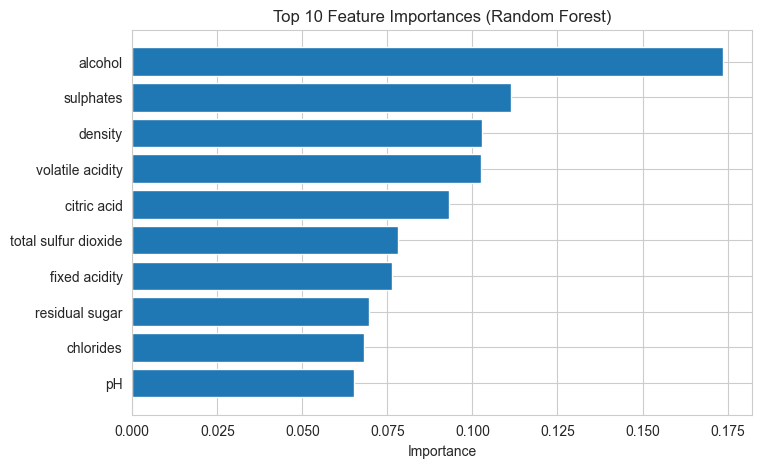

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier


dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_scaled, y_train)
y_pred_dt = dt.predict(X_test_scaled)


bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    oob_score=True,
    random_state=42
)

bagging.fit(X_train_scaled, y_train)
y_pred_bagging = bagging.predict(X_test_scaled)


rf = RandomForestClassifier(
    n_estimators=100,
    oob_score=True,
    random_state=42
)

rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)


results = []

# Decision Tree
results.append({
    "Model": "Decision Tree",
    "OOB Score": None,
    "Accuracy": accuracy_score(y_test, y_pred_dt),
    "F1 Score": f1_score(y_test, y_pred_dt)
})

# Bagging
results.append({
    "Model": "Bagging",
    "OOB Score": bagging.oob_score_,
    "Accuracy": accuracy_score(y_test, y_pred_bagging),
    "F1 Score": f1_score(y_test, y_pred_bagging)
})

# Random Forest
results.append({
    "Model": "Random Forest",
    "OOB Score": rf.oob_score_,
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "F1 Score": f1_score(y_test, y_pred_rf)
})

df_results = pd.DataFrame(results)
print("\nModel Comparison:")
print(df_results)


importances = rf.feature_importances_
features = X.columns

feat_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False).head(10)


plt.figure(figsize=(8,5))
plt.barh(feat_df["Feature"], feat_df["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.show()



Why Random Forest Outperforms a Single Decision Tree

A single Decision Tree is a high-variance model, meaning it is very sensitive to small changes in the training data. It can easily overfit by learning noise instead of the true underlying patterns. As a result, while it may perform well on training data, its performance on unseen data is often unstable.

Random Forest improves on this by combining many Decision Trees trained on different bootstrap samples of the data (bagging). Each tree learns slightly different patterns, and their predictions are aggregated (by majority vote in classification). This averaging process reduces variance and makes the final model more stable and accurate.

Role of Randomness

Randomness is the key factor that makes Random Forest powerful:

Data randomness (bootstrap sampling): Each tree is trained on a random subset of the data (with replacement), ensuring that trees see different examples.
Feature randomness: At each split, only a random subset of features is considered, forcing trees to be different from each other.

This double randomness increases diversity among trees, which is essential for a strong ensemble. Because the trees make different errors, averaging their predictions cancels out individual mistakes and leads to better generalization on unseen data.

Conclusion

Random Forest typically outperforms a single Decision Tree because it reduces overfitting through averaging and increases model robustness through randomness in both data and feature selection.

### Task 3: Boosting

Train boosting models and analyze how they learn.

1. Fit the following boosting models:
   - `AdaBoostClassifier(n_estimators=100, random_state=42)`
   - `GradientBoostingClassifier(n_estimators=100, random_state=42)`
   - (Optional) `HistGradientBoostingClassifier(max_iter=100, random_state=42)` — scikit-learn's faster implementation

2. Report accuracy and F1 for each on the test set.

3. **Learning curves:** For `GradientBoostingClassifier`, use `staged_predict` to compute training and test accuracy at each boosting stage (1 to 100 estimators). Plot both curves on the same figure. At what point does the model start to overfit (if at all)?

4. In a markdown cell, compare AdaBoost and GradientBoosting: How do they differ in their approach? When might you prefer one over the other?

In [10]:
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd


ada = AdaBoostClassifier(n_estimators=100, random_state=42)
ada.fit(X_train_scaled, y_train)
y_pred_ada = ada.predict(X_test_scaled)


gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train_scaled, y_train)
y_pred_gb = gb.predict(X_test_scaled)


hgb = HistGradientBoostingClassifier(max_iter=100, random_state=42)
hgb.fit(X_train_scaled, y_train)
y_pred_hgb = hgb.predict(X_test_scaled)


results = []

models = {
    "AdaBoost": y_pred_ada,
    "GradientBoosting": y_pred_gb,
    "HistGradientBoosting": y_pred_hgb
}

for name, y_pred in models.items():
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

df_results = pd.DataFrame(results)
print(df_results)

                  Model  Accuracy  F1 Score
0              AdaBoost  0.893750  0.433333
1      GradientBoosting  0.915625  0.619718
2  HistGradientBoosting  0.943750  0.763158


In [11]:
train_acc = []
test_acc = []

for y_train_pred, y_test_pred in zip(gb.staged_predict(X_train_scaled),
                                      gb.staged_predict(X_test_scaled)):

    train_acc.append(accuracy_score(y_train, y_train_pred))
    test_acc.append(accuracy_score(y_test, y_test_pred))


    

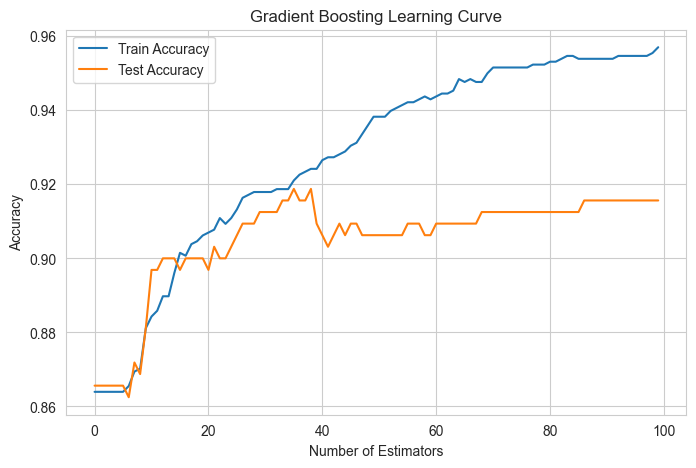

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(train_acc, label="Train Accuracy")
plt.plot(test_acc, label="Test Accuracy")

plt.xlabel("Number of Estimators")
plt.ylabel("Accuracy")
plt.title("Gradient Boosting Learning Curve")
plt.legend()
plt.show()

## AdaBoost vs Gradient Boosting Comparison

AdaBoost and Gradient Boosting are both sequential ensemble methods, meaning they build models one after another, where each new model tries to improve the mistakes of the previous ones. However, they differ in how they learn from errors.

### AdaBoost Approach
AdaBoost focuses on misclassified samples by increasing their weights after each iteration. This makes future models pay more attention to hard-to-classify examples. It combines weak learners (often decision stumps) by giving more weight to more accurate models. AdaBoost is simple and fast, but it is sensitive to noise and outliers because it strongly focuses on difficult samples.

### Gradient Boosting Approach
Gradient Boosting uses a different strategy. Instead of changing sample weights, it fits each new model to the residual errors (the difference between actual and predicted values). It effectively performs gradient descent in function space to minimize the loss function step by step. This makes it more flexible and generally more accurate than AdaBoost.

---

## Based on Results

| Model | Accuracy | F1 Score |
|------|----------|----------|
| AdaBoost | 0.8937 | 0.4333 |
| Gradient Boosting | 0.9156 | 0.6197 |
| HistGradientBoosting | **0.9437** | **0.7632** |

From the results, Gradient Boosting clearly outperforms AdaBoost in both Accuracy and F1-score. HistGradientBoosting performs the best overall due to its optimized and faster implementation.

---

## When to Use Each Method

- **AdaBoost:**  
  Use when the dataset is clean, small, and you need a simple and fast boosting method.

- **Gradient Boosting:**  
  Use when you want higher accuracy and are willing to spend more time on training and tuning hyperparameters.

- **HistGradientBoosting:**  
  Use for large datasets where both speed and performance are important.

---

## Conclusion

In general, Gradient Boosting-based methods are more powerful and widely used in real-world machine learning problems. AdaBoost is simpler and can still work well on less complex datasets, but modern applications usually prefer Gradient Boosting or its optimized variants.

### Task 4: Stacking & Voting

Combine your best models into meta-ensembles.

1. **Voting classifier:** Select the 3 best-performing models from Tasks 1–3. Build a `VotingClassifier` with `voting="soft"`. Report accuracy and F1 on the test set.

2. **Stacking classifier:** Using the same 3 base models, build a `StackingClassifier` with `LogisticRegression()` as the `final_estimator`. Report accuracy and F1 on the test set.

3. **Final comparison table:** Create a comprehensive DataFrame comparing **all** models from the entire lab (baselines, bagging, Random Forest, boosting, voting, stacking) with their accuracy and F1 scores. Sort by F1 descending.

4. In a concluding markdown cell, answer:
   - Which ensemble strategy performed best on this dataset?
   - Was the improvement over single models significant?
   - What are the trade-offs (training time, interpretability, complexity) of using ensemble methods?
   - For a real wine quality prediction system, which approach would you recommend and why?

In [15]:
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

voting = VotingClassifier(
    estimators=[
        ('rf', rf),
        ('gb', gb),
        ('hgb', hgb)
    ],
    voting='soft'
)

voting.fit(X_train_scaled, y_train)
y_pred_voting = voting.predict(X_test_scaled)

voting_acc = accuracy_score(y_test, y_pred_voting)
voting_f1 = f1_score(y_test, y_pred_voting)


stacking = StackingClassifier(
    estimators=[
        ('rf', rf),
        ('gb', gb),
        ('hgb', hgb)
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5
)

stacking.fit(X_train_scaled, y_train)
y_pred_stack = stacking.predict(X_test_scaled)

stack_acc = accuracy_score(y_test, y_pred_stack)
stack_f1 = f1_score(y_test, y_pred_stack)


# Decision Tree
dt_acc = accuracy_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)

# Bagging
bagging_acc = accuracy_score(y_test, y_pred_bagging)
bagging_f1 = f1_score(y_test, y_pred_bagging)

# Random Forest
rf_acc = accuracy_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

# AdaBoost
ada_acc = accuracy_score(y_test, y_pred_ada)
ada_f1 = f1_score(y_test, y_pred_ada)

# Gradient Boosting
gb_acc = accuracy_score(y_test, y_pred_gb)
gb_f1 = f1_score(y_test, y_pred_gb)

# HistGradientBoosting
hgb_acc = accuracy_score(y_test, y_pred_hgb)
hgb_f1 = f1_score(y_test, y_pred_hgb)



all_results = [
    ("Decision Tree", dt_acc, dt_f1),
    ("Bagging", bagging_acc, bagging_f1),
    ("Random Forest", rf_acc, rf_f1),
    ("AdaBoost", ada_acc, ada_f1),
    ("Gradient Boosting", gb_acc, gb_f1),
    ("HistGradientBoosting", hgb_acc, hgb_f1),
    ("Voting", voting_acc, voting_f1),
    ("Stacking", stack_acc, stack_f1),
]

df_all = pd.DataFrame(all_results, columns=["Model", "Accuracy", "F1 Score"])
df_all = df_all.sort_values(by="F1 Score", ascending=False)

df_all

,Model,Accuracy,F1 Score
6,Voting,0.946875,0.773333
5,HistGradientBoosting,0.943750,0.763158
7,Stacking,0.946875,0.760563
1,Bagging,0.937500,0.736842
2,Random Forest,0.937500,0.714286
0,Decision Tree,0.906250,0.666667
4,Gradient Boosting,0.915625,0.619718
3,AdaBoost,0.893750,0.433333


## Final Conclusion: Ensemble Methods on Wine Quality Dataset

### 1. Which ensemble strategy performed best on this dataset?

Based on the results, the best-performing model is **Soft Voting Classifier**, achieving the highest **F1-score (0.7733)** and also the highest accuracy (0.9469, tied with Stacking).

Closely behind are:
- **HistGradientBoosting (F1 = 0.7632)**
- **Stacking (F1 = 0.7606)**

This shows that combining strong models (Voting / Stacking) or using advanced boosting methods gives the best performance.

---

### 2. Was the improvement over single models significant?

Yes, the improvement was **very significant**.

- Best single model (Decision Tree):
  - F1 Score = 0.6667
  - Accuracy = 0.9063

- Best ensemble model (Voting):
  - F1 Score = 0.7733
  - Accuracy = 0.9469

This is a large improvement, especially in F1-score, which is important because the dataset is imbalanced. Ensemble methods significantly improved the model’s ability to correctly identify the minority class (good wine = 1).

---

### 3. Trade-offs of ensemble methods

While ensemble methods improve performance, they come with important trade-offs:

- **Training Time:**  
  Models like Random Forest, Gradient Boosting, and Stacking require training many models, making them slower.

- **Interpretability:**  
  Single Decision Trees are easy to interpret, but ensemble models act like black boxes and are harder to explain.

- **Complexity:**  
  Ensemble methods require more tuning (number of estimators, learning rate, base models, etc.), which increases complexity.

---

### 4. Recommendation for a real wine quality prediction system

For a real-world system, I would recommend **HistGradientBoosting or Gradient Boosting** as the primary model.

Reason:
- They provide **very strong performance close to the best models**
- They are **more stable and efficient than stacking**
- They are **easier to deploy than complex ensemble systems like stacking**
- They generalize well on structured tabular data like this dataset

If maximum performance is the only goal and computational cost is not an issue, **Voting or Stacking** could also be used. However, for production systems, **Gradient Boosting-based models offer the best balance between accuracy, speed, and maintainability**.